In [ ]:
import numpy as np
import pandas as pd
import torch
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import dataloader
import torch.optim as optim
import torchvision.utils as vutils
import matplotlib.pyplot as plt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
dataset = datasets.MNIST(root="", download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.55MB/s]


In [ ]:
dataLoader = dataloader.DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self, inputSize=50, outputSize=28*28):
        super().__init__()

        self.Model = nn.Sequential(
            nn.Linear(inputSize, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, outputSize),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.Model(x)
        return x.view(-1, 1, 28, 28)

In [ ]:
class Discriminator(nn.Module):
  def __init__(self, imageSize=28*28):
    super().__init__()

    self.Model = nn.Sequential(

       nn.Linear(imageSize,512),
       nn.ReLU(),

       nn.Linear(512,256),
       nn.ReLU(),

       nn.Linear(256,1),
       nn.Sigmoid(),
    )

  def forward(self, imageSize=28*28):
    imgFlat = imageSize.view(imageSize.size(0), -1)
    return self.Model(imgFlat)

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
criteria = nn.BCELoss()

In [ ]:
genOptimizer = optim.Adam(generator.parameters(), lr=0.0005, betas=(0.5, 0.999))
disOptimizer = optim.Adam(discriminator.parameters(), lr=0.00003, betas=(0.5, 0.999))

In [ ]:
epochs = 70

Epoch :1/70, Discriminator Loss : 0.7015, Generator Loss : 0.6920


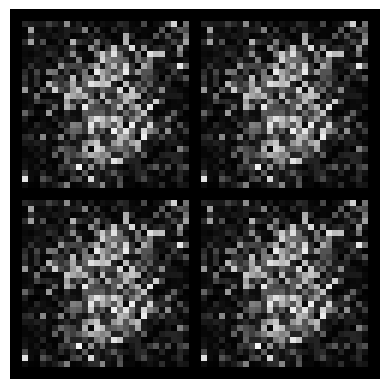

Epoch :2/70, Discriminator Loss : 0.6937, Generator Loss : 0.7480


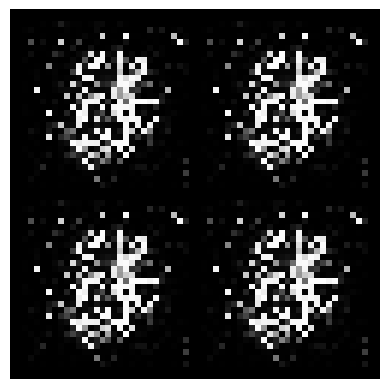

Epoch :3/70, Discriminator Loss : 0.6889, Generator Loss : 0.7528


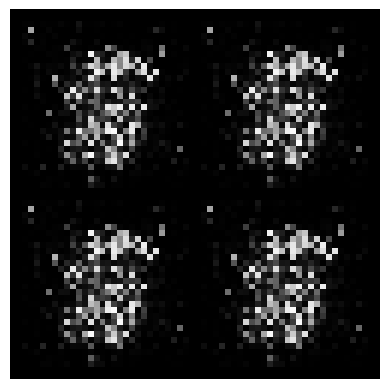

Epoch :4/70, Discriminator Loss : 0.6890, Generator Loss : 0.7524


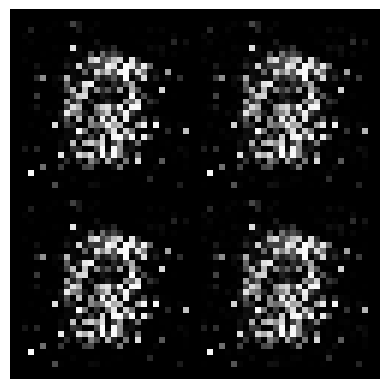

Epoch :5/70, Discriminator Loss : 0.6876, Generator Loss : 0.7833


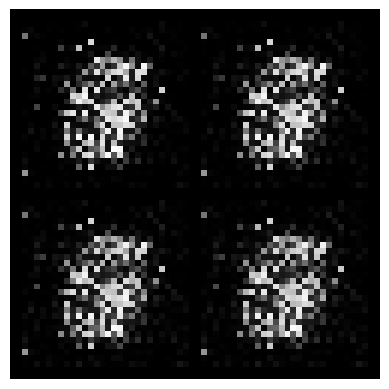

Epoch :6/70, Discriminator Loss : 0.6895, Generator Loss : 0.7761


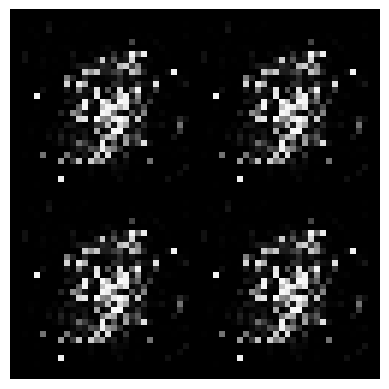

Epoch :7/70, Discriminator Loss : 0.6884, Generator Loss : 0.7809


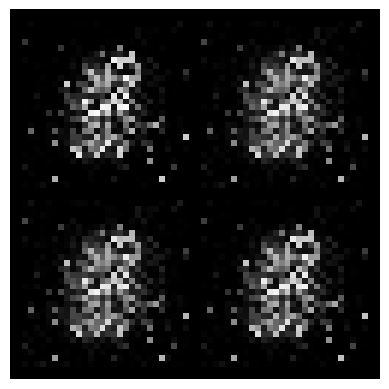

Epoch :8/70, Discriminator Loss : 0.6897, Generator Loss : 0.7689


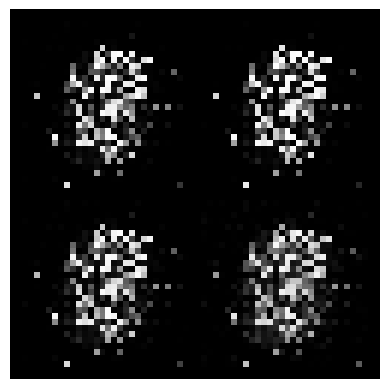

Epoch :9/70, Discriminator Loss : 0.6883, Generator Loss : 0.7789


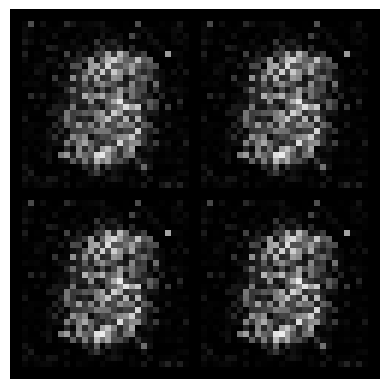

Epoch :10/70, Discriminator Loss : 0.6885, Generator Loss : 0.7764


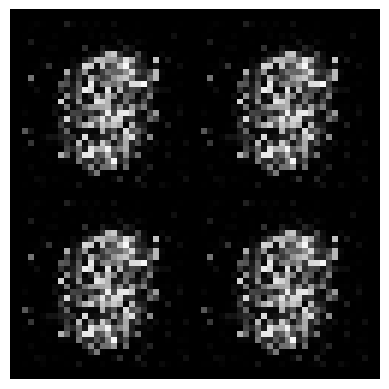

Epoch :11/70, Discriminator Loss : 0.6887, Generator Loss : 0.7816


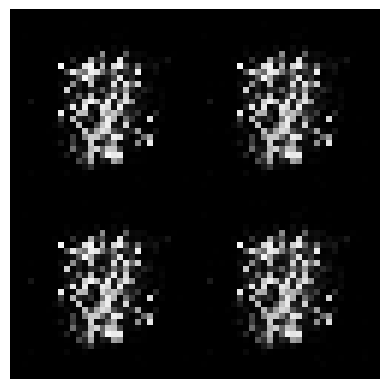

Epoch :12/70, Discriminator Loss : 0.6903, Generator Loss : 0.7734


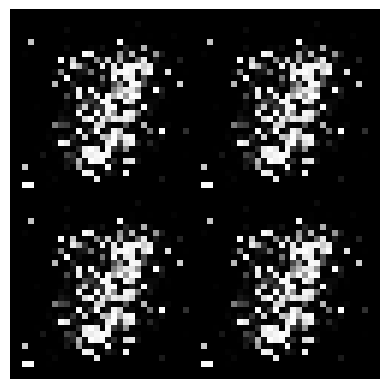

Epoch :13/70, Discriminator Loss : 0.6901, Generator Loss : 0.7713


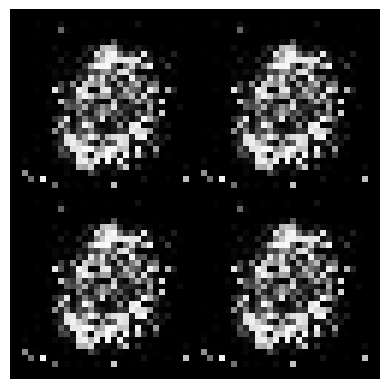

Epoch :14/70, Discriminator Loss : 0.6895, Generator Loss : 0.7828


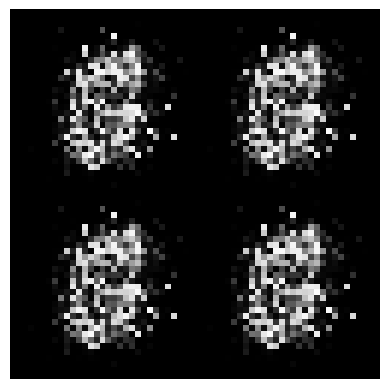

Epoch :15/70, Discriminator Loss : 0.6893, Generator Loss : 0.7782


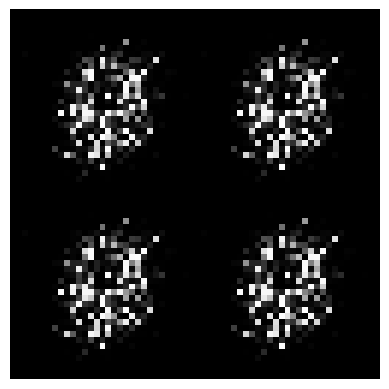

Epoch :16/70, Discriminator Loss : 0.6889, Generator Loss : 0.7813


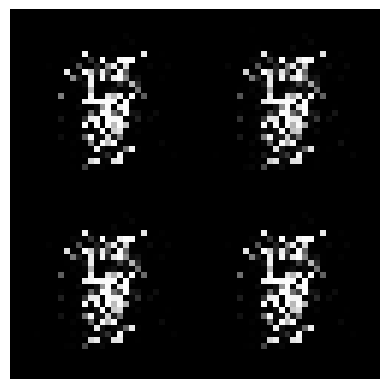

Epoch :17/70, Discriminator Loss : 0.6899, Generator Loss : 0.7770


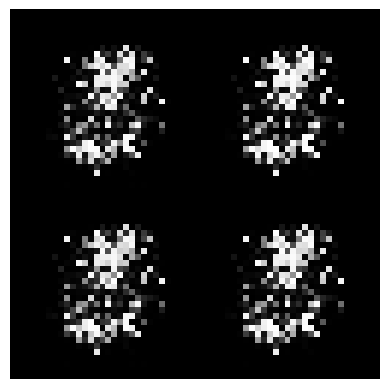

Epoch :18/70, Discriminator Loss : 0.6899, Generator Loss : 0.7776


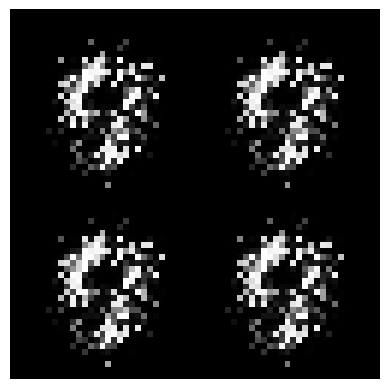

Epoch :19/70, Discriminator Loss : 0.6886, Generator Loss : 0.7809


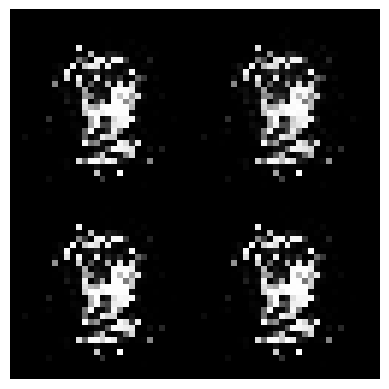

Epoch :20/70, Discriminator Loss : 0.6875, Generator Loss : 0.7803


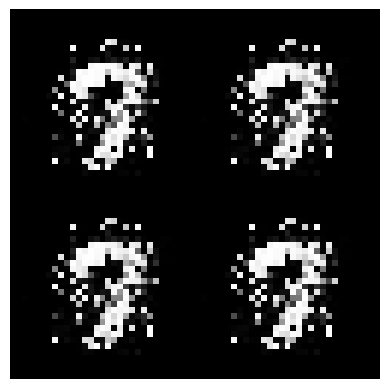

Epoch :21/70, Discriminator Loss : 0.6875, Generator Loss : 0.7871


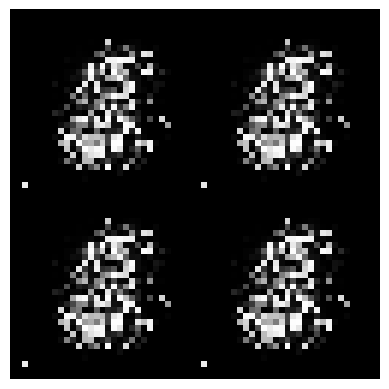

Epoch :22/70, Discriminator Loss : 0.6891, Generator Loss : 0.7798


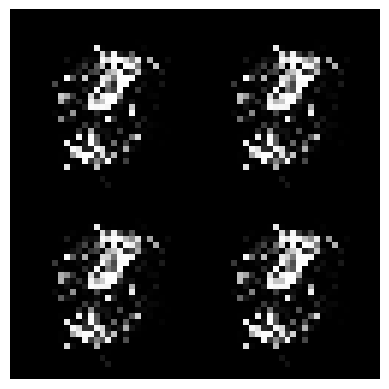

Epoch :23/70, Discriminator Loss : 0.6830, Generator Loss : 0.7811


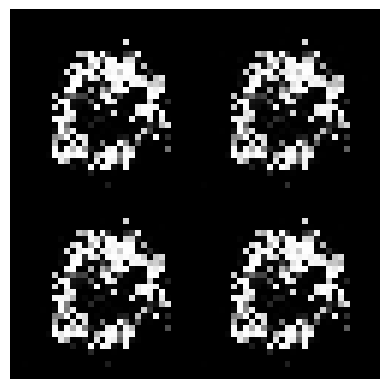

Epoch :24/70, Discriminator Loss : 0.6878, Generator Loss : 0.7873


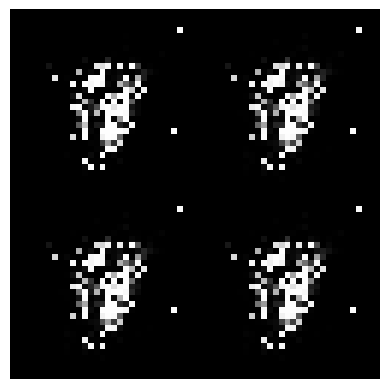

Epoch :25/70, Discriminator Loss : 0.6898, Generator Loss : 0.7795


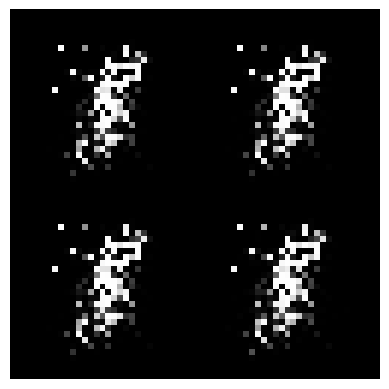

Epoch :26/70, Discriminator Loss : 0.6879, Generator Loss : 0.7766


In [ ]:
fixed_z = torch.randn(4, 50).to(device)
for epoch in range(epochs):

    for realImg, _ in dataLoader:
        realImg = realImg.to(device)
        batchSize = realImg.size(0)

        # labels (label smoothing for real)
        fakeLabels = torch.zeros(batchSize, 1).to(device)
        realLabels = torch.full((batchSize, 1), 0.9).to(device)

        # ======================
        # Train Discriminator
        # ======================
        z = torch.randn(batchSize, 50).to(device)
        fakeImg = generator(z)

        realLoss = criteria(discriminator(realImg), realLabels)
        fakeLoss = criteria(discriminator(fakeImg.detach()), fakeLabels)

        totalLoss = (realLoss + fakeLoss)/2

        disOptimizer.zero_grad()
        totalLoss.backward()
        disOptimizer.step()

        # ======================
        # Train Generator
        # ======================
        for _ in range(2):
            z = torch.randn(batchSize, 50).to(device)
            fakeImg = generator(z)

            genLoss = criteria(discriminator(fakeImg), realLabels)

            genOptimizer.zero_grad()
            genLoss.backward()
            genOptimizer.step()

    # ======================
    # Print losses
    # ======================
    print(f"Epoch :{epoch+1}/{epochs}, "
          f"Discriminator Loss : {totalLoss.item():.4f}, "
          f"Generator Loss : {genLoss.item():.4f}")

    with torch.no_grad():
      fake_samples = generator(fixed_z).cpu()

      grid = vutils.make_grid(fake_samples * 0.5 + 0.5, nrow=2)

      plt.imshow(grid.permute(1,2,0))
      plt.axis("off")
      plt.show()

